In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ==========================================
# PART 1: DATA LOADING & INITIAL INSPECTION
# ==========================================

# Load the dataset 
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(titanic_url)

print("--- Titanic First 10 Rows ---")
print(df_titanic.head(10))

print("\n--- Titanic Structure & Quality Inspection ---")
print(df_titanic.info())
print(f"\nShape of Dataset: {df_titanic.shape}")
print(f"Duplicate Rows: {df_titanic.duplicated().sum()}")
print("\nMissing Values per Column:")
print(df_titanic.isnull().sum())

# ==========================================
# PART 2: DATA PREPROCESSING
# ==========================================

# A. Missing Value Treatment
# 1. Age: Impute with Median because Age distribution is skewed.
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

# 2. Embarked: Impute with Mode (most frequent port) since it's categorical and missing only 2 values.
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0])

# 3. Cabin: Drop column entirely. Over 77% of data is missing, making imputation inaccurate.
df_titanic.drop(columns=['Cabin'], inplace=True)

# B. Duplicate Removal
df_titanic.drop_duplicates(inplace=True)

# C. Outlier Treatment (Fare Column)
# Using IQR method to cap extreme Fare outliers rather than removing them to preserve sample size.
Q1 = df_titanic['Fare'].quantile(0.25)
Q3 = df_titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers to upper and lower bounds
df_titanic['Fare'] = np.clip(df_titanic['Fare'], lower_bound, upper_bound)

# Drop irrelevant columns that don't contribute to ML predictive power
df_titanic.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# D. Categorical Variable Encoding
# Label Encoding for binary 'Sex' column
label_enc = LabelEncoder()
df_titanic['Sex'] = label_enc.fit_transform(df_titanic['Sex']) # Male: 1, Female: 0

# One-Hot Encoding for 'Embarked' column (Creates dummy variables)
df_titanic = pd.get_dummies(df_titanic, columns=['Embarked'], drop_first=True)

# E. Feature Scaling
# StandardScaler scales features to have mean=0 and variance=1. Critical for distance-based algorithms.
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_titanic[numerical_cols] = scaler.fit_transform(df_titanic[numerical_cols])

# Save Cleaned Dataset
df_titanic.to_csv("cleaned_titanic.csv", index=False)
print("\nCleaned Titanic dataset saved successfully!")

--- Titanic First 10 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCar

In [2]:
# ==========================================
# PART 1: DATA LOADING & INITIAL INSPECTION
# ==========================================

# Load the dataset
iris_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
colnames = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df_iris = pd.read_csv(iris_url, names=colnames)

print("--- Iris First 10 Rows ---")
print(df_iris.head(10))

print("\n--- Iris Structure & Quality Inspection ---")
print(df_iris.info())
print(f"Duplicate Rows Found: {df_iris.duplicated().sum()}")

# ==========================================
# PART 2: DATA PREPROCESSING
# ==========================================

# A. Missing Value Treatment
# Iris dataset naturally has no missing values, but good to run a check.
print(f"Missing Values:\n{df_iris.isnull().sum()}")

# B. Duplicate Removal
# Remove duplicates to avoid bias in machine learning models
df_iris.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df_iris.shape}")

# C. Outlier Treatment (Sepal Width often has minor outliers)
# Retaining outliers here as they represent natural biological variations in flowers.

# D. Categorical Variable Encoding
# Label Encoding the target column 'species' to convert text classes to numerical values (0, 1, 2)
df_iris['species'] = label_enc.fit_transform(df_iris['species'])

# E. Feature Scaling
# Using MinMaxScaler to scale features between 0 and 1, preserving original distribution bounds.
from sklearn.preprocessing import MinMaxScaler
mx_scaler = MinMaxScaler()
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df_iris[feature_cols] = mx_scaler.fit_transform(df_iris[feature_cols])

# Save Cleaned Dataset
df_iris.to_csv("cleaned_iris.csv", index=False)
print("\nCleaned Iris dataset saved successfully!")

--- Iris First 10 Rows ---
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa

--- Iris Structure & Quality Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        ---

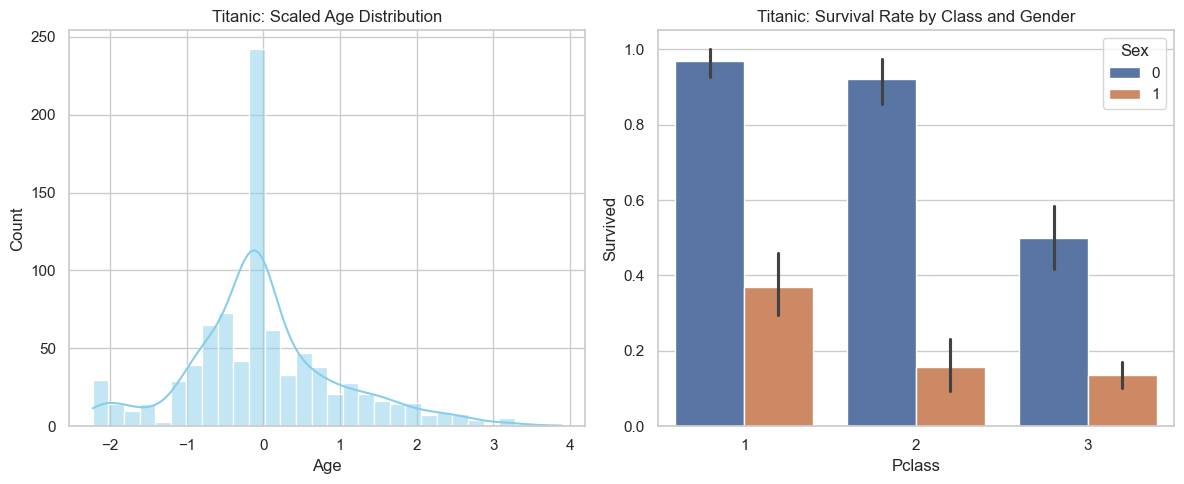

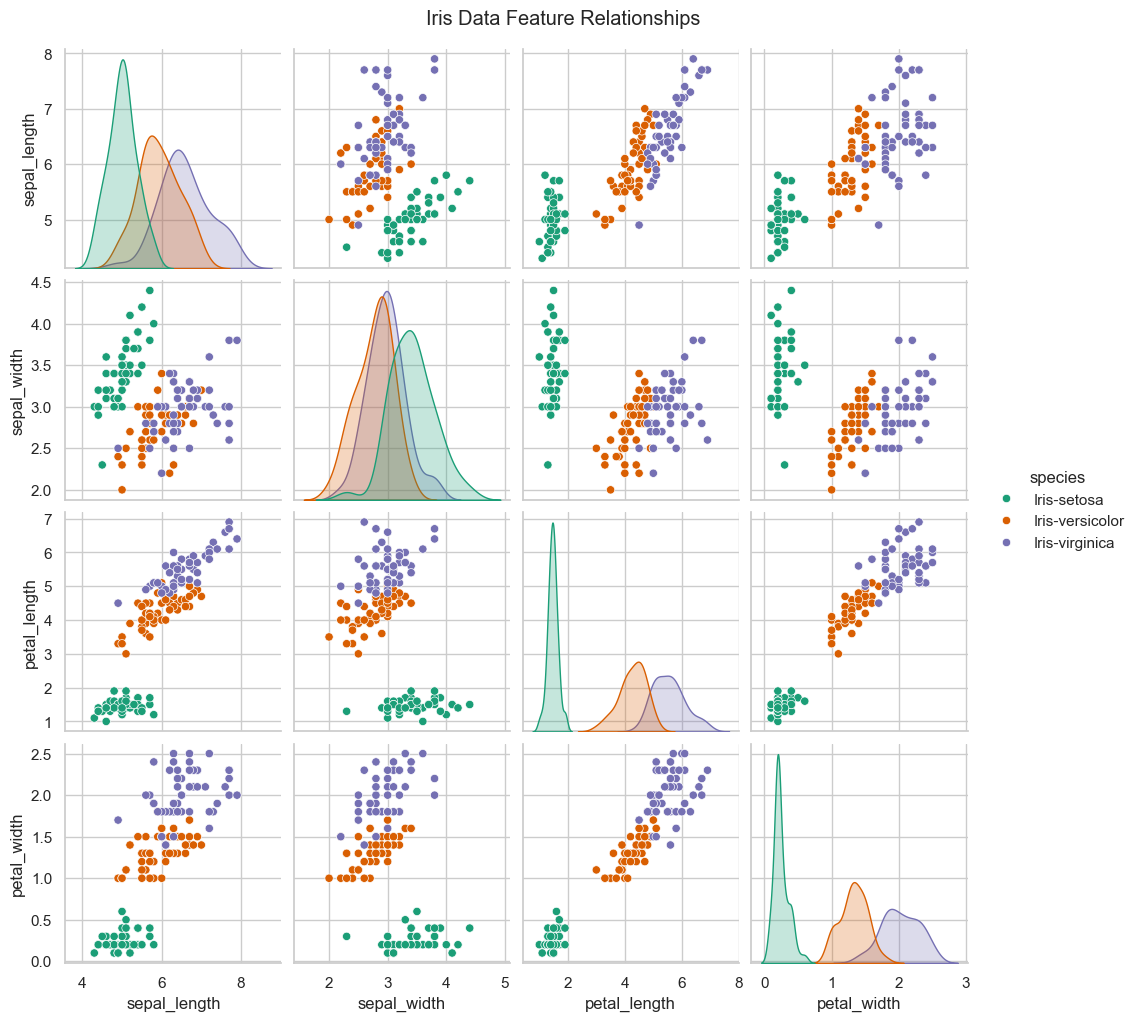

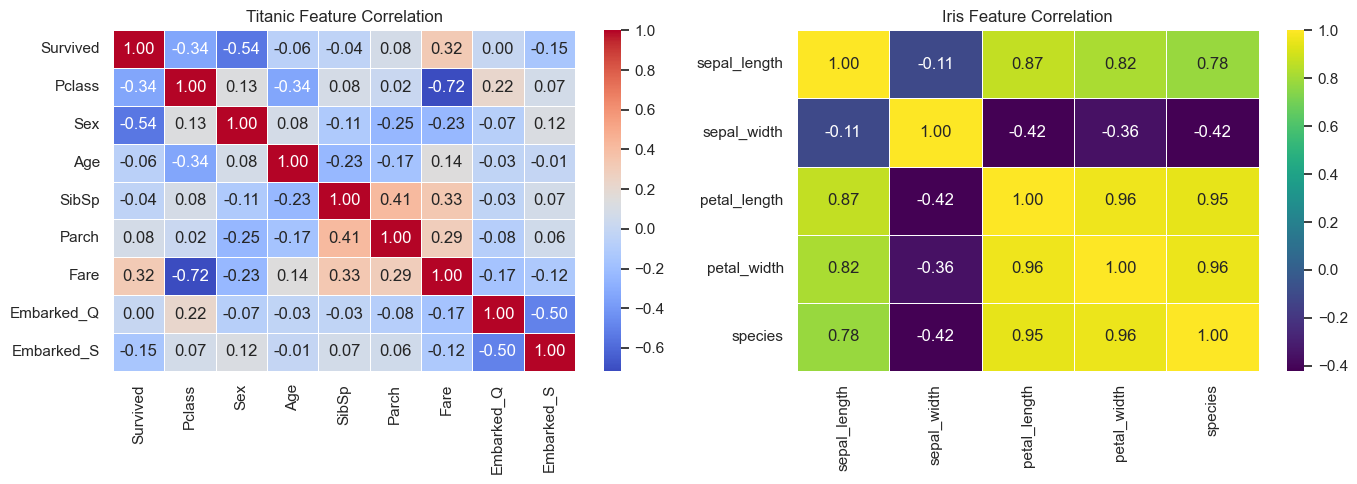

In [3]:
# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Titanic Univariate & Bivariate Visualizations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_titanic['Age'], kde=True, color='skyblue')
plt.title('Titanic: Scaled Age Distribution')

plt.subplot(1, 2, 2)
sns.barplot(data=df_titanic, x='Pclass', y='Survived', hue='Sex')
plt.title('Titanic: Survival Rate by Class and Gender')
plt.tight_layout()
plt.show()

# 2. Iris Pairplot (Shows both distributions and scatter relationships simultaneously)
# Note: Re-loading unscaled data temporarily for intuitive EDA visuals
df_iris_raw = pd.read_csv(iris_url, names=colnames)
sns.pairplot(df_iris_raw, hue='species', palette='Dark2')
plt.suptitle('Iris Data Feature Relationships', y=1.02)
plt.show()

# 3. Correlation Heatmaps
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(df_titanic.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Titanic Feature Correlation')

plt.subplot(1, 2, 2)
sns.heatmap(df_iris.corr(), annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Iris Feature Correlation')

plt.tight_layout()
plt.show()